# Monte Carlo Methods: LLN, CLT, and the $N^{-1/2}$ error rate

This experiment estimates $\pi$ and a definite integral using random samples. It separates three related ideas: convergence of a running estimate, the distribution of repeated estimates, and the rate at which root mean squared error decreases.

## 1. Problem

Draw independent points $(U_i,V_i)$ uniformly from the unit square and define

$$Y_i=4\,\mathbf{1}\{U_i^2+V_i^2\leq1\}.$$

The quarter circle has area $\pi/4$, so $E[Y_i]=\pi$. We ask:

1. Does the running average $\widehat\pi_N=N^{-1}\sum_{i=1}^NY_i$ approach $\pi$?
2. Across repeated experiments, does the standardized error become approximately normal?
3. Does the estimator's RMSE decrease like $N^{-1/2}$?
4. Does the same Monte Carlo principle estimate the integral $\int_0^1e^{-x^2}\,dx$?

## 2. Mathematical Background

The strong law of large numbers states that for independent, identically distributed variables with finite mean,

$$\overline Y_N\xrightarrow{\text{a.s.}}E[Y_1].$$

The central limit theorem describes fluctuations around that limit:

$$\frac{\sqrt{N}(\overline Y_N-E[Y_1])}{\sqrt{\operatorname{Var}(Y_1)}}
\xrightarrow{d}N(0,1).$$

For a general integral $I=\int_a^bf(x)\,dx$, if $U\sim\operatorname{Uniform}(a,b)$, then

$$I=(b-a)E[f(U)].$$

Thus the sample average of $(b-a)f(U_i)$ is an unbiased Monte Carlo estimator of the integral.

## 3. Theoretical Result

Let $p=P(U_i^2+V_i^2\leq1)=\pi/4$. Since $Y_i=4$ with probability $p$ and zero otherwise,

$$E[Y_i]=4p=\pi,$$

$$\operatorname{Var}(Y_i)=16p(1-p)=4\pi-\pi^2.$$

Therefore

$$\operatorname{SE}(\widehat\pi_N)=\frac{\sqrt{4\pi-\pi^2}}{\sqrt N}=O(N^{-1/2}).$$

Doubling the number of samples reduces typical error only by a factor of $1/\sqrt2$; reducing error by a factor of ten requires roughly one hundred times as many samples. A single absolute-error curve can rise temporarily, so the rate is tested with RMSE across many independent replications.

## 4. Numerical Experiment

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from scipy.special import erf
from scipy.stats import norm

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "src" / "monte_carlo.py").exists(), "Run from the repository root or notebooks/"
sys.path.insert(0, str(project_root))

from src.monte_carlo import (
    replicate_pi_estimates,
    root_mean_squared_error,
    running_mean,
)

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)

n_samples = 1_000_000
rng = np.random.default_rng(20261006)
x_points = rng.random(n_samples)
y_points = rng.random(n_samples)
inside = x_points**2 + y_points**2 <= 1
running_pi = 4 * running_mean(inside.astype(float))

pi_estimate = running_pi[-1]
pi_standard_error = np.sqrt(4 * np.pi - np.pi**2) / np.sqrt(n_samples)
print(f"Pi estimate with {n_samples:,} points: {pi_estimate:.6f}")
print(f"Absolute error: {abs(pi_estimate-np.pi):.6f}")
print(f"Theoretical standard error: {pi_standard_error:.6f}")
print(f"Approximate 95% interval: [{pi_estimate-1.96*pi_standard_error:.6f}, "
      f"{pi_estimate+1.96*pi_standard_error:.6f}]")

Pi estimate with 1,000,000 points: 3.140864
Absolute error: 0.000729
Theoretical standard error: 0.001642
Approximate 95% interval: [3.137645, 3.144083]


In [2]:
sample_sizes = np.array([100, 300, 1_000, 3_000, 10_000, 30_000])
n_replications = 400
error_rng = np.random.default_rng(20261007)
empirical_rmse = []
for size in sample_sizes:
    estimates = replicate_pi_estimates(int(size), n_replications, error_rng)
    empirical_rmse.append(root_mean_squared_error(estimates, np.pi))
empirical_rmse = np.array(empirical_rmse)
theoretical_rmse = np.sqrt(4 * np.pi - np.pi**2) / np.sqrt(sample_sizes)
fitted_slope, fitted_intercept = np.polyfit(np.log(sample_sizes), np.log(empirical_rmse), 1)

print(f"{'N':>8} {'empirical RMSE':>18} {'theoretical RMSE':>20}")
for size, empirical, theoretical in zip(sample_sizes, empirical_rmse, theoretical_rmse):
    print(f"{size:8,d} {empirical:18.6f} {theoretical:20.6f}")
print(f"Log-log fitted slope: {fitted_slope:.4f}; theoretical slope: -0.5000")

       N     empirical RMSE     theoretical RMSE
     100           0.164460             0.164218
     300           0.102555             0.094812
   1,000           0.052237             0.051930
   3,000           0.030920             0.029982
  10,000           0.016495             0.016422
  30,000           0.009320             0.009481
Log-log fitted slope: -0.5074; theoretical slope: -0.5000


In [3]:
clt_size, clt_replications = 1_000, 5_000
clt_estimates = replicate_pi_estimates(
    clt_size, clt_replications, np.random.default_rng(20261008)
)
single_draw_sd = np.sqrt(4 * np.pi - np.pi**2)
standardized_errors = np.sqrt(clt_size) * (clt_estimates - np.pi) / single_draw_sd

integral_samples = 500_000
integral_rng = np.random.default_rng(20261009)
uniforms = integral_rng.random(integral_samples)
integrand_values = np.exp(-uniforms**2)
running_integral = running_mean(integrand_values)
exact_integral = np.sqrt(np.pi) * erf(1) / 2
integral_standard_error = np.std(integrand_values, ddof=1) / np.sqrt(integral_samples)

print(f"Standardized CLT sample mean: {np.mean(standardized_errors):.4f}")
print(f"Standardized CLT sample variance: {np.var(standardized_errors, ddof=1):.4f}")
print(f"Integral estimate: {running_integral[-1]:.6f}")
print(f"Exact integral: {exact_integral:.6f}")
print(f"Integral standard error estimate: {integral_standard_error:.6f}")

Standardized CLT sample mean: 0.0142
Standardized CLT sample variance: 1.0132
Integral estimate: 0.746684
Exact integral: 0.746824
Integral standard error estimate: 0.000284


The RMSE experiment uses independent repetitions for each sample size. The CLT experiment standardizes 5,000 independent estimates using the exact variance $4\pi-\pi^2$. The integral experiment uses a separate random stream.

## 5. Visualization

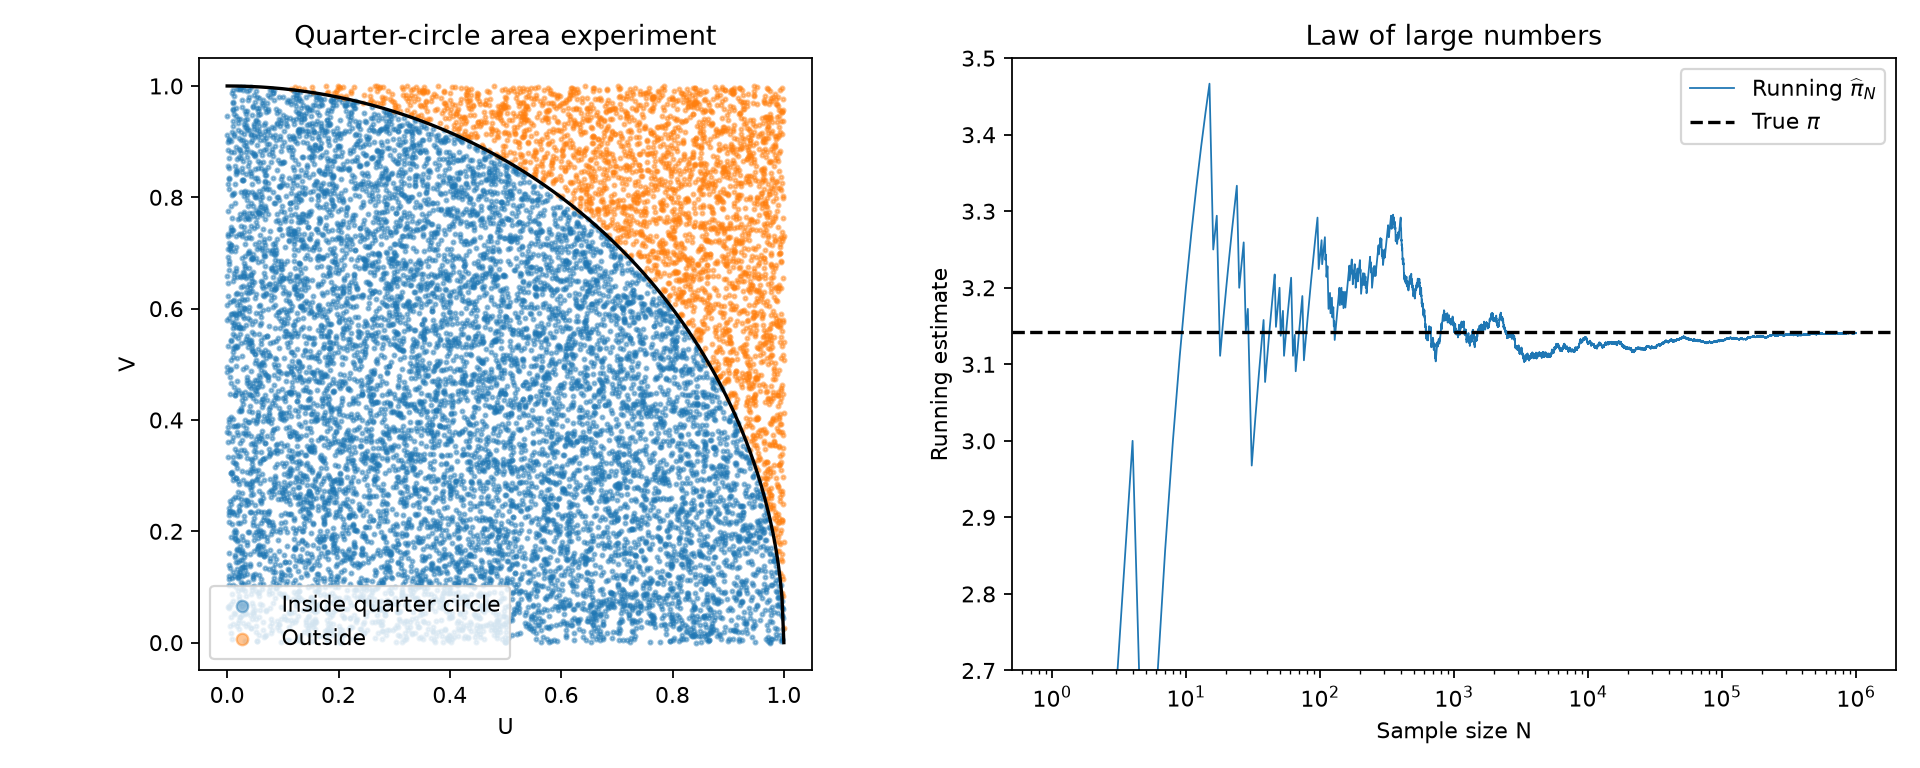

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
display_count = 12_000
axes[0].scatter(x_points[:display_count][inside[:display_count]],
                y_points[:display_count][inside[:display_count]], s=3, alpha=0.45,
                label="Inside quarter circle")
axes[0].scatter(x_points[:display_count][~inside[:display_count]],
                y_points[:display_count][~inside[:display_count]], s=3, alpha=0.45,
                label="Outside")
quarter_x = np.linspace(0, 1, 300)
axes[0].plot(quarter_x, np.sqrt(1-quarter_x**2), color="black", linewidth=1.5)
axes[0].set(aspect="equal", title="Quarter-circle area experiment", xlabel="U", ylabel="V")
axes[0].legend(markerscale=3)

indices = np.arange(1, n_samples + 1)
axes[1].plot(indices, running_pi, linewidth=0.8, label=r"Running $\widehat\pi_N$")
axes[1].axhline(np.pi, color="black", linestyle="--", label=r"True $\pi$")
axes[1].set(xscale="log", title="Law of large numbers", xlabel="Sample size N",
            ylabel="Running estimate", ylim=(2.7, 3.5))
axes[1].legend()
fig.tight_layout()
path = figure_dir / "monte_carlo_pi_convergence.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

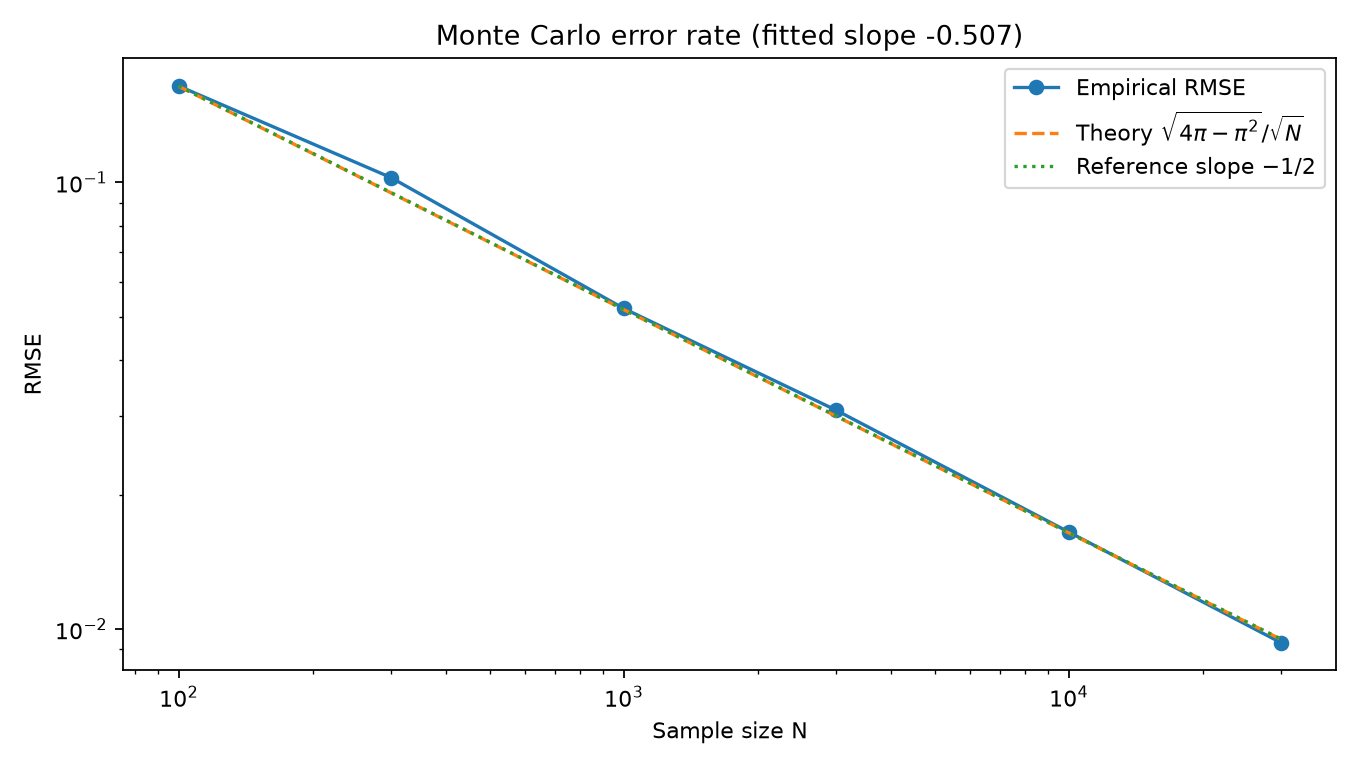

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.loglog(sample_sizes, empirical_rmse, "o-", label="Empirical RMSE")
ax.loglog(sample_sizes, theoretical_rmse, "--", label=r"Theory $\sqrt{4\pi-\pi^2}/\sqrt{N}$")
reference = empirical_rmse[0] * np.sqrt(sample_sizes[0] / sample_sizes)
ax.loglog(sample_sizes, reference, ":", label=r"Reference slope $-1/2$")
ax.set(title=f"Monte Carlo error rate (fitted slope {fitted_slope:.3f})",
       xlabel="Sample size N", ylabel="RMSE")
ax.legend()
fig.tight_layout()
path = figure_dir / "monte_carlo_error_rate.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

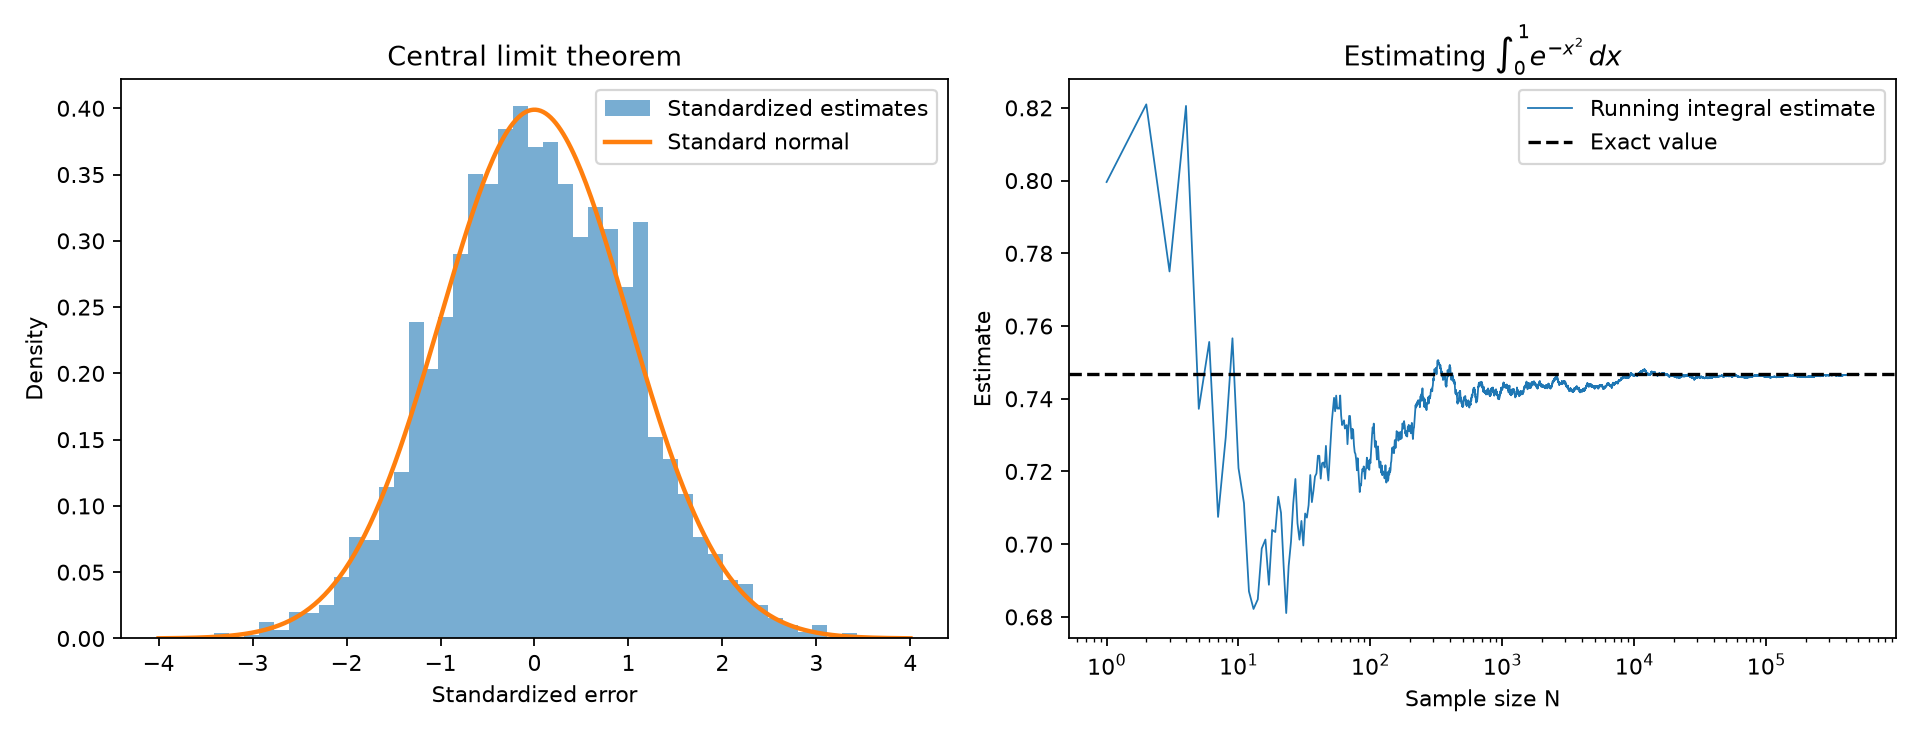

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
z_grid = np.linspace(-4, 4, 300)
axes[0].hist(standardized_errors, bins=45, density=True, alpha=0.6,
             label="Standardized estimates")
axes[0].plot(z_grid, norm.pdf(z_grid), linewidth=2, label="Standard normal")
axes[0].set(title="Central limit theorem", xlabel="Standardized error", ylabel="Density")
axes[0].legend()

integral_indices = np.arange(1, integral_samples + 1)
axes[1].plot(integral_indices, running_integral, linewidth=0.8,
             label="Running integral estimate")
axes[1].axhline(exact_integral, color="black", linestyle="--", label="Exact value")
axes[1].set(xscale="log", title=r"Estimating $\int_0^1 e^{-x^2}\,dx$",
            xlabel="Sample size N", ylabel="Estimate")
axes[1].legend()
fig.tight_layout()
path = figure_dir / "monte_carlo_clt_and_integral.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

## 6. Comparison with Theory

The running $\pi$ and integral estimates settle near their exact targets, illustrating the law of large numbers. They still fluctuate and need not move closer at every new sample.

On log-log axes, an error law $cN^{-1/2}$ appears as a straight line with slope $-1/2$. The fitted empirical RMSE slope can therefore be compared directly with $-0.5$. The standardized repeated estimates are compared with the standard normal density, checking the shape predicted by the central limit theorem rather than only its variance.

## 7. Interpretation

Monte Carlo converts an expectation into a sample average. Its great advantage is generality: the same idea estimates a geometric area, an integral, or an expected financial payoff. Its basic convergence rate is slow and largely independent of dimension: standard error decreases as $N^{-1/2}$.

The law of large numbers explains consistency, while the central limit theorem quantifies uncertainty at large but finite $N$. The CLT supports approximate confidence intervals, but these intervals rely on independent sampling and finite variance.

RMSE combines bias and variance. The $\pi$ estimator is unbiased, so its RMSE equals its standard deviation theoretically. Repeated simulation makes the rate visible without pretending a single random error sequence must be monotone.

## 8. Limitations

- Pseudorandom samples are deterministic given a seed and only approximate ideal independent uniforms.
- The normal approximation can be poor for small samples or rare-event estimators.
- Plain Monte Carlo has the slow $N^{-1/2}$ rate; variance reduction, quasi-Monte Carlo, or problem-specific numerical integration may be much more efficient.
- A fitted slope depends on the selected sample sizes and replication count. It is evidence consistent with the theoretical rate, not a proof of it.